# Brain tumor classification using ConvNeXTiny, acc= 95.43%****



In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/figshare-braintumor/tumor/2912.mat
/kaggle/input/figshare-braintumor/tumor/2011.mat
/kaggle/input/figshare-braintumor/tumor/3027.mat
/kaggle/input/figshare-braintumor/tumor/1912.mat
/kaggle/input/figshare-braintumor/tumor/3023.mat
/kaggle/input/figshare-braintumor/tumor/101.mat
/kaggle/input/figshare-braintumor/tumor/1194.mat
/kaggle/input/figshare-braintumor/tumor/851.mat
/kaggle/input/figshare-braintumor/tumor/2106.mat
/kaggle/input/figshare-braintumor/tumor/1850.mat
/kaggle/input/figshare-braintumor/tumor/2911.mat
/kaggle/input/figshare-braintumor/tumor/1731.mat
/kaggle/input/figshare-braintumor/tumor/1014.mat
/kaggle/input/figshare-braintumor/tumor/296.mat
/kaggle/input/figshare-braintumor/tumor/1716.mat
/kaggle/input/figshare-braintumor/tumor/124.mat
/kaggle/input/figshare-braintumor/tumor/2541.mat
/kaggle/input/figshare-braintumor/tumor/1082.mat
/kaggle/input/figshare-braintumor/tumor/1719.mat
/kaggle/input/figshare-braintumor/tumor/2551.mat
/kaggle/input/figshare-b

# Importing Libraries

In [2]:
import numpy as np
import h5py
import os
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ConvNeXtTiny
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical


In [3]:
# Set dataset path
dataset_path = "/kaggle/input/figshare-braintumor/tumor"

# Function to load data and image preprocessing

In [4]:
def load_mat_data_v73(path):
    """Loads MRI images and labels from MATLAB v7.3 .mat files"""
    images = []
    labels = []
    
    for file in os.listdir(path):
        if file.endswith(".mat"):
            file_path = os.path.join(path, file)
            
            with h5py.File(file_path, "r") as mat:
                # Extract image
                img = np.array(mat["cjdata"]["image"])
                label = np.array(mat["cjdata"]["label"])[0, 0] - 1  # Convert to 0-indexed
                
                # Resize image for ConvNeXt (224x224)
                img_resized = cv2.resize(img, (224, 224))
                img_resized = img_resized / 255.0  # Normalize
                
                images.append(img_resized)
                labels.append(label)
    
    return np.array(images), np.array(labels)


# Loading Dataset

In [5]:
# Load dataset
X, y = load_mat_data_v73(dataset_path)

# Converting to RGB and one hot encoding labels

In [6]:
# Convert grayscale to RGB for ConvNeXt
X = np.expand_dims(X, axis=-1)  # Add channel dimension
X = np.repeat(X, 3, axis=-1)  # Convert grayscale to RGB

# One-hot encode labels (since it's a classification task)
y = to_categorical(y, num_classes=3)

# Train-test split

In [7]:
# Split dataset into train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# ConvNeXTiny model

In [8]:
# Load ConvNeXt-Tiny as the base model
base_model = ConvNeXtTiny(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# Freeze base model layers
base_model.trainable = False

# Add more layers to improve feature learning
x = layers.GlobalAveragePooling2D()(base_model.output)  # Feature extraction
x = layers.BatchNormalization()(x)  # Normalize activations

x = layers.Dense(1024, activation="relu")(x)  # Increased Dense layer size
x = layers.Dropout(0.5)(x)  # Reduce overfitting

x = layers.Dense(512, activation="relu")(x)  # Another Dense layer
x = layers.BatchNormalization()(x)  

x = layers.Dense(256, activation="relu")(x)  # Added layer
x = layers.Dropout(0.3)(x)  # Slight dropout
# Final output layer (3 classes)
output = layers.Dense(3, activation="softmax")(x)  

# Compile model
model = keras.Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),  # Lower LR for stability
              loss="categorical_crossentropy", metrics=["accuracy"])

# Summary
model.summary()

111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ convnext_tiny_prestem_no… │ (None, 224, 224, 3)    │              0 │ input_layer[0][0]      │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ convnext_tiny_stem        │ (None, 56, 56, 96)     │          4,896 │ convnext_tiny_prestem… │
│ (Sequential)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ convnext_tiny_stage_0_bl… │ (None, 56, 56, 96)     │          4,800 │ convnext_tiny_stem[0]… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ convnext_tiny_stage_0_bl… │ (None, 56, 56, 96)     │            192 │ convnext_tiny_stage_0… │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ convnext_tiny_stage_0_bl… │ (None, 56, 56, 384)    │         37,248 │ convnext_tiny_stage_0… │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ convnext_tiny_stage_0_bl… │ (None, 56, 56, 384)    │              0 │ convnext_tiny_stage_0… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ convnext_tiny_stage_0_bl… │ (None, 56, 56, 96)     │         36,960 │ convnext_tiny_stage_0… │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ convnext_tiny_stage_0_bl… │ (None, 56, 56, 96)     │             96 │ convnext_tiny_stage_0… │
│ (LayerScale)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ convnext_tiny_stage_0_bl… │ (None, 56, 56, 96)     │              0 │ convnext_tiny_stage_0… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 56, 56, 96)     │              0 │ convnext_tiny_stem[0]… │
│                           │                        │                │ convnext_tiny_stage_0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ convnext_tiny_stage_0_bl… │ (None, 56, 56, 96)     │          4,800 │ add[0][0]              │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ convnext_tiny_stage_0_bl… │ (None, 56, 56, 96)     │            192 │ convnext_tiny_stage_0… │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ convnext_tiny_stage_0

 Total params: 29,269,603 (111.65 MB)

 Trainable params: 1,446,915 (5.52 MB)

 Non-trainable params: 27,822,688 (106.14 MB)

In [9]:
# Train
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=35, batch_size=32)

Epoch 1/35
77/77 ━━━━━━━━━━━━━━━━━━━━ 42s 325ms/step - accuracy: 0.5379 - loss: 1.0471 - val_accuracy: 0.6281 - val_loss: 0.9769
Epoch 2/35
77/77 ━━━━━━━━━━━━━━━━━━━━ 11s 143ms/step - accuracy: 0.7666 - loss: 0.5804 - val_accuracy: 0.7765 - val_loss: 0.7910
Epoch 3/35
77/77 ━━━━━━━━━━━━━━━━━━━━ 11s 145ms/step - accuracy: 0.8154 - loss: 0.4466 - val_accuracy: 0.7863 - val_loss: 0.6389
Epoch 4/35
77/77 ━━━━━━━━━━━━━━━━━━━━ 11s 147ms/step - accuracy: 0.8419 - loss: 0.3745 - val_accuracy: 0.8352 - val_loss: 0.4982
Epoch 5/35
77/77 ━━━━━━━━━━━━━━━━━━━━ 11s 148ms/step - accuracy: 0.8649 - loss: 0.3182 - val_accuracy: 0.8711 - val_loss: 0.3692
Epoch 6/35
77/77 ━━━━━━━━━━━━━━━━━━━━ 12s 151ms/step - accuracy: 0.8871 - loss: 0.3160 - val_accuracy: 0.8891 - val_loss: 0.2959
Epoch 7/35
77/77 ━━━━━━━━━━━━━━━━━━━━ 12s 152ms/step - accuracy: 0.9042 - loss: 0.2554 - val_accuracy: 0.8956 - val_loss: 0.2670
Epoch 8/35
77/77 ━━━━━━━━━━━━━━━━━━━━ 12s 154ms/step - accuracy: 0.9204 - loss: 0.2178 - val_accu

In [10]:
# Evaluate model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - accuracy: 0.9146 - loss: 0.3050
Test Accuracy: 0.9135


In [11]:
print(f"Test Loss: {test_loss:.4f}")

Test Loss: 0.2693


# Fine tuning

In [12]:
# Unfreeze some layers
base_model.trainable = True

# Recompile with lower learning rate
model.compile(optimizer=keras.optimizers.Adam(1e-5), loss="categorical_crossentropy", metrics=["accuracy"])

# Fine-tune
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=30, batch_size=32)


Epoch 1/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 110s 818ms/step - accuracy: 0.9809 - loss: 0.0486 - val_accuracy: 0.9119 - val_loss: 0.2762
Epoch 2/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 36s 465ms/step - accuracy: 0.9851 - loss: 0.0484 - val_accuracy: 0.9233 - val_loss: 0.2726
Epoch 3/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 35s 457ms/step - accuracy: 0.9831 - loss: 0.0536 - val_accuracy: 0.9184 - val_loss: 0.3013
Epoch 4/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 35s 451ms/step - accuracy: 0.9926 - loss: 0.0219 - val_accuracy: 0.9266 - val_loss: 0.2678
Epoch 5/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 35s 456ms/step - accuracy: 0.9951 - loss: 0.0195 - val_accuracy: 0.9331 - val_loss: 0.2151
Epoch 6/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 35s 455ms/step - accuracy: 0.9944 - loss: 0.0214 - val_accuracy: 0.9331 - val_loss: 0.2483
Epoch 7/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 35s 453ms/step - accuracy: 0.9933 - loss: 0.0240 - val_accuracy: 0.9282 - val_loss: 0.2339
Epoch 8/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 35s 454ms/step - accuracy: 0.9979 - loss: 0.0112 - val_acc

# Accuracy and loss

In [13]:
oss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc * 100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - accuracy: 0.9489 - loss: 0.2006
Test Accuracy: 95.43%


In [14]:
print(f"Test Loss: {oss:.4f}")

Test Loss: 0.1626


# Visualization of test accuracy and loss

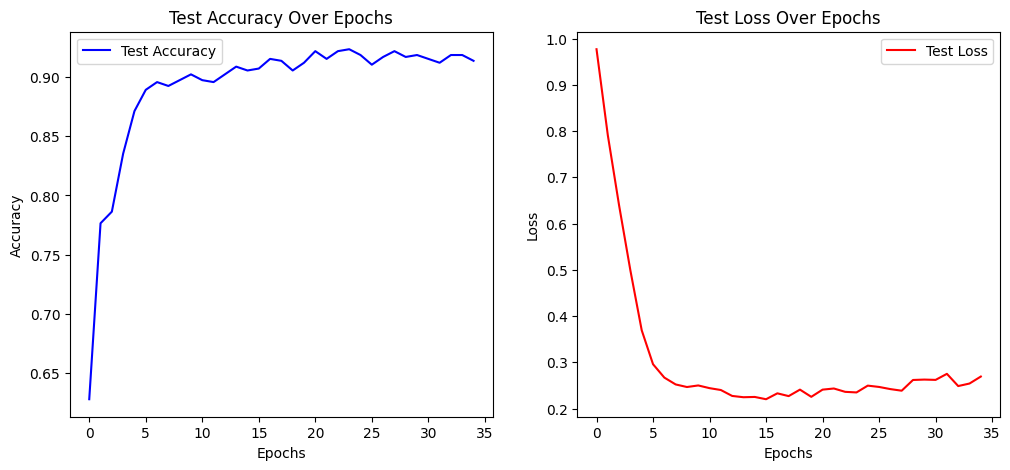

In [15]:
import matplotlib.pyplot as plt

# Plot test accuracy and test loss
plt.figure(figsize=(12, 5))

# Subplot 1: Test Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['val_accuracy'], label='Test Accuracy', color='blue')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Test Accuracy Over Epochs')
plt.legend()

# Subplot 2: Test Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['val_loss'], label='Test Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Test Loss Over Epochs')
plt.legend()

plt.show()


# Prediction

In [18]:
class_names = ["Meningioma", "Glioma", "Pituitary"]

In [19]:
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Convert one-hot encoded y_test to class indices
y_true_classes = np.argmax(y_test, axis=1)

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step


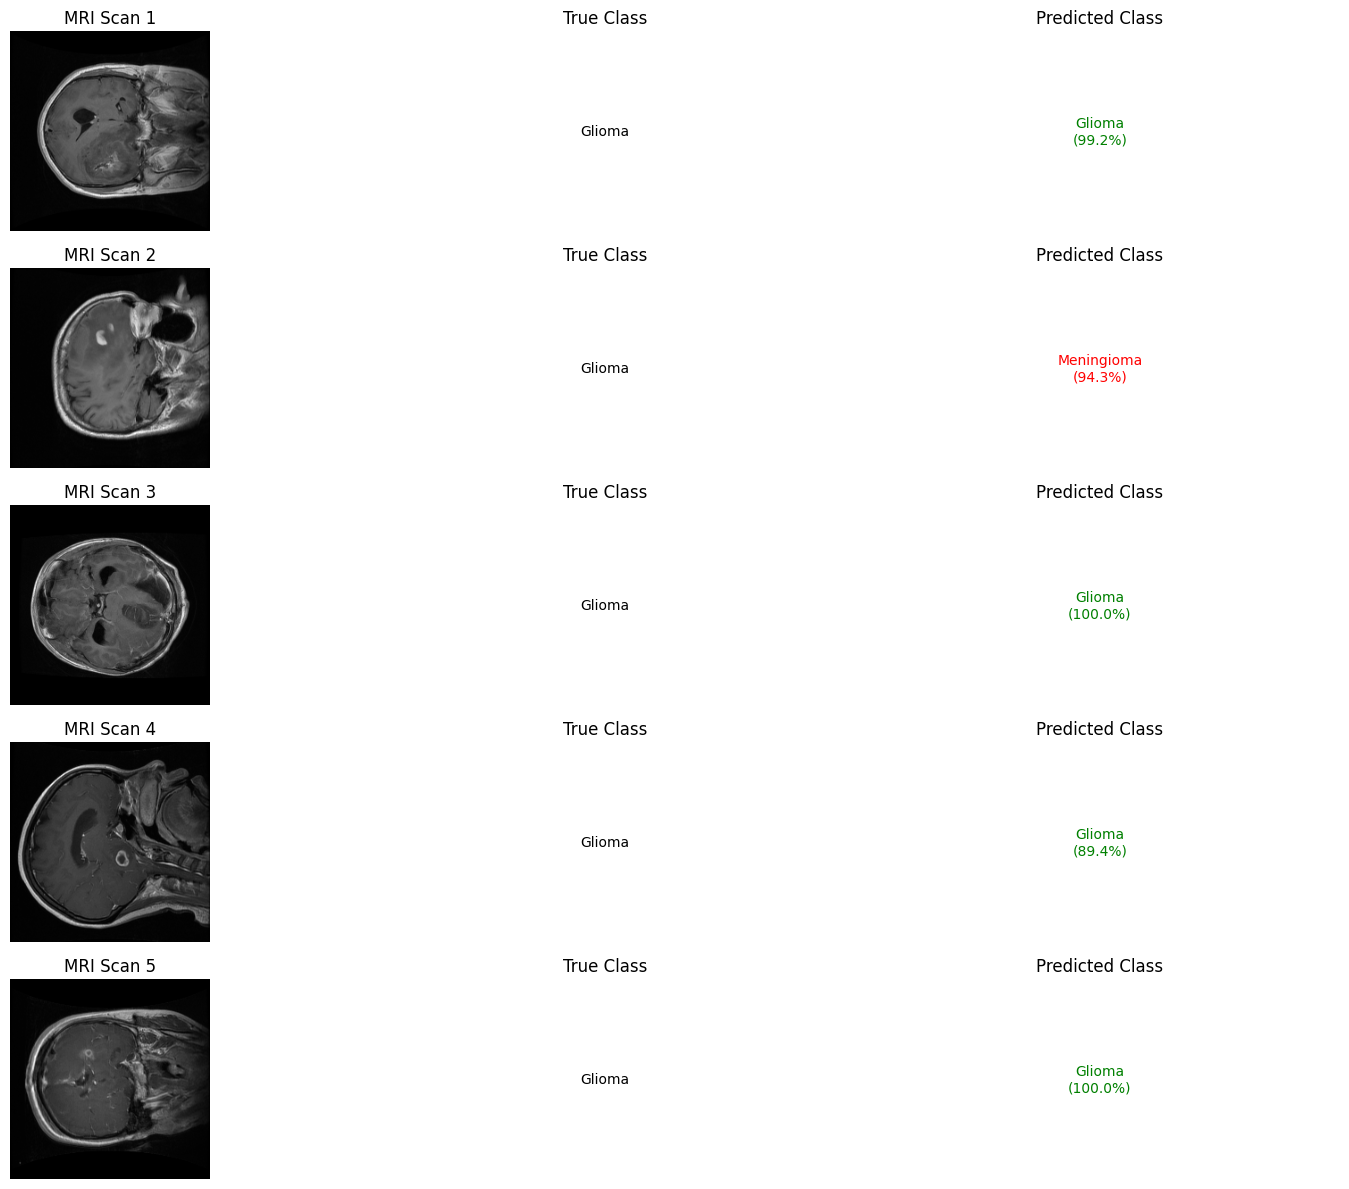

In [21]:
plt.figure(figsize=(15, 12))
for i in range(5):
    plt.subplot(5, 3, i*3+1)
    plt.imshow(X_test[i][:, :, 0], cmap='gray')  # Show first channel of RGB
    plt.title(f"MRI Scan {i+1}")
    plt.axis('off')
    
    plt.subplot(5, 3, i*3+2)
    plt.text(0.5, 0.5, class_names[y_true_classes[i]], 
             ha='center', va='center', fontsize=10)
    plt.title("True Class")
    plt.axis('off')
    
    plt.subplot(5, 3, i*3+3)
    confidence = np.max(y_pred_probs[i]) * 100
    color = 'green' if y_true_classes[i] == y_pred_classes[i] else 'red'
    plt.text(0.5, 0.5, f"{class_names[y_pred_classes[i]]}\n({confidence:.1f}%)", 
             ha='center', va='center', fontsize=10, color=color)
    plt.title("Predicted Class")
    plt.axis('off')

plt.tight_layout()
plt.show()